# 01 — Data Collection & Exploratory Data Analysis (EDA)

**Research Questions yang dibahas:**
- RQ1: Berapa probabilitas sebuah PR di pandas mendapatkan review dalam 7 hari pertama?
- RQ2: Apakah rata-rata jumlah issue per minggu berubah setelah rilis pandas 2.0?
- RQ3: Berapa probabilitas sebuah issue membutuhkan lebih dari 30 hari untuk ditutup?

**Member:** Rafaeli Niamonio Marundrury — Data Engineer & Estimation Analyst

**Tujuan notebook ini:** Mengumpulkan data dari GitHub API, membersihkan data, dan melakukan eksplorasi awal sebelum analisis statistik.

## AI Usage Disclosure

**Member:** Rafaeli Niamonio Marundrury — Data Engineer & Estimation Analyst | **Tools used:** Claude

| Task | Tool | Prompt summary | Output modified? |
| ---- | ---- | -------------- | ---------------- |
| Membuat script pengumpulan data | Claude | "Buatkan kode untuk menarik data issues dan PR dari GitHub API" | Ya — pengecekan token dan error handling ditambahkan manual |
| Membuat grafik distribusi data | Claude | "Buatkan grafik untuk melihat sebaran data" | Ya — warna dan label diubah manual |
| Membuat grafik tren bulanan | Claude | "Buatkan grafik tren per bulan" | Ya — anotasi ditambahkan manual |

**Written entirely without AI:** Semua cell interpretasi markdown, kesimpulan EDA, dan identifikasi pola data.

---

# BAGIAN 1 — PENGUMPULAN DATA

In [ ]:
# Install library jika belum ada
# !pip install requests pandas matplotlib seaborn

In [ ]:
import requests
import pandas as pd
import numpy as np
import time
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# ── Konfigurasi ──
GITHUB_TOKEN = "ghp_xxxxxxxxxxxxxxxxxx"   # ganti di sini
REPO         = "pandas-dev/pandas"
BASE_URL     = f"https://api.github.com/repos/{REPO}"
HEADERS      = {"Authorization": f"token {GITHUB_TOKEN}"}
MAX_PAGES    = 30    # ~3.000 item per endpoint

PANDAS_V2    = "2023-04-03"              # tanggal rilis pandas 2.0

os.makedirs('../data/raw',   exist_ok=True)
os.makedirs('../data/clean', exist_ok=True)

print('Library berhasil diimport.')

Library berhasil diimport.


In [6]:
# Cek apakah token valid
cek = requests.get("https://api.github.com/user", headers=HEADERS)
if cek.status_code == 200:
    print(f"✓ Login sebagai: {cek.json()['login']}")
else:
    print(f"✗ Token tidak valid: {cek.json().get('message')}")
    print("  Ganti GITHUB_TOKEN di cell sebelumnya.")

✓ Login sebagai: rafaelinm


## 1.1 Fungsi Pengambilan Data

In [7]:
def fetch(endpoint, params={}):
    """Ambil semua halaman dari satu endpoint GitHub API."""
    results = []
    page    = 1

    while page <= MAX_PAGES:
        params['page']     = page
        params['per_page'] = 100

        resp = requests.get(f"{BASE_URL}/{endpoint}", headers=HEADERS, params=params)

        if resp.status_code == 403:
            print("  Rate limit, tunggu 60 detik...")
            time.sleep(60)
            continue

        data = resp.json()

        if isinstance(data, dict):   # API mengembalikan error
            print(f"  API error: {data.get('message')}")
            break

        if not data:
            break

        results.extend(data)
        print(f"  {endpoint} — halaman {page}, total: {len(results)}")
        page += 1
        time.sleep(0.5)

    return results

print('Fungsi fetch() siap digunakan.')

Fungsi fetch() siap digunakan.


## 1.2 Ambil Issues — Sebelum DAN Sesudah pandas 2.0

**Perbaikan:** GitHub API mengembalikan data terbaru terlebih dahulu, sehingga 30 halaman (3.000 item) hanya mencakup periode sesudah pandas 2.0. Untuk mendapatkan data **sebelum** pandas 2.0, kita fetch secara terpisah menggunakan parameter `until` (issues yang dibuat sebelum tanggal rilis).

In [8]:
print('📥 Mengambil issues sesudah pandas 2.0...')
raw_issues_post = fetch('issues', {'state': 'closed', 'since': PANDAS_V2})

print('\n📥 Mengambil issues sebelum pandas 2.0...')
# 'until' tidak didukung langsung, gunakan 'before' via search API atau
# filter manual setelah fetch dengan parameter sort=created & direction=asc
raw_issues_pre = fetch('issues', {
    'state'    : 'closed',
    'sort'     : 'created',
    'direction': 'asc',         # mulai dari yang paling lama (sebelum v2.0)
})

# Gabungkan, deduplikasi berdasarkan nomor issue
raw_issues_all = {item['number']: item
                  for item in (raw_issues_pre + raw_issues_post)
                  if 'pull_request' not in item}
raw_issues = list(raw_issues_all.values())

issues = []
for item in raw_issues:
    issues.append({
        'id'        : item['number'],
        'created_at': item['created_at'],
        'closed_at' : item.get('closed_at'),
        'labels'    : '|'.join(lb['name'] for lb in item['labels']),
        'user'      : item['user']['login'],
        'comments'  : item.get('comments', 0),
    })

df_issues = pd.DataFrame(issues)
print(f'\n✓ Issues terkumpul: {len(df_issues):,} baris')
df_issues.head(3)

📥 Mengambil issues sesudah pandas 2.0...
  issues — halaman 1, total: 100
  issues — halaman 2, total: 200
  issues — halaman 3, total: 300
  issues — halaman 4, total: 400
  issues — halaman 5, total: 500
  issues — halaman 6, total: 600
  issues — halaman 7, total: 700
  issues — halaman 8, total: 800
  issues — halaman 9, total: 900
  issues — halaman 10, total: 1000
  issues — halaman 11, total: 1100
  issues — halaman 12, total: 1200
  issues — halaman 13, total: 1300
  issues — halaman 14, total: 1400
  issues — halaman 15, total: 1500
  issues — halaman 16, total: 1600
  issues — halaman 17, total: 1700
  issues — halaman 18, total: 1800
  issues — halaman 19, total: 1900
  issues — halaman 20, total: 2000
  issues — halaman 21, total: 2100
  issues — halaman 22, total: 2200
  issues — halaman 23, total: 2300
  issues — halaman 24, total: 2400
  issues — halaman 25, total: 2500
  issues — halaman 26, total: 2600
  issues — halaman 27, total: 2700
  issues — halaman 28, total: 28

,id,created_at,closed_at,labels,user,comments
0,1,2010-09-29T00:45:31Z,2011-02-19T23:13:48Z,,wesm,1
1,2,2010-09-29T00:50:13Z,2010-12-17T02:57:33Z,,wesm,1
2,3,2010-09-29T00:50:52Z,2011-01-01T23:50:12Z,,wesm,1


## 1.3 Ambil Pull Requests

In [9]:
print('📥 Mengambil pull requests...')
raw_prs = fetch('pulls', {'state': 'closed'})

prs = []
for item in raw_prs:
    merged    = item.get('merged_at') is not None
    created   = item['created_at']
    end       = item.get('merged_at') or item.get('closed_at')
    days_open = None
    if end:
        days_open = (
            datetime.fromisoformat(end.replace('Z','')) -
            datetime.fromisoformat(created.replace('Z',''))
        ).days

    prs.append({
        'id'        : item['number'],
        'created_at': created,
        'closed_at' : item.get('closed_at'),
        'merged_at' : item.get('merged_at'),
        'merged'    : int(merged),
        'days_open' : days_open,
        'user'      : item['user']['login'],
        'comments'  : item.get('comments', 0),
    })

df_prs = pd.DataFrame(prs)
print(f'\n✓ PR terkumpul: {len(df_prs):,} baris')
df_prs.head(3)

📥 Mengambil pull requests...
  pulls — halaman 1, total: 100
  pulls — halaman 2, total: 200
  pulls — halaman 3, total: 300
  pulls — halaman 4, total: 400
  pulls — halaman 5, total: 500
  pulls — halaman 6, total: 600
  pulls — halaman 7, total: 700
  pulls — halaman 8, total: 800
  pulls — halaman 9, total: 900
  pulls — halaman 10, total: 1000
  pulls — halaman 11, total: 1100
  pulls — halaman 12, total: 1200
  pulls — halaman 13, total: 1300
  pulls — halaman 14, total: 1400
  pulls — halaman 15, total: 1500
  pulls — halaman 16, total: 1600
  pulls — halaman 17, total: 1700
  pulls — halaman 18, total: 1800
  pulls — halaman 19, total: 1900
  pulls — halaman 20, total: 2000
  pulls — halaman 21, total: 2100
  pulls — halaman 22, total: 2200
  pulls — halaman 23, total: 2300
  pulls — halaman 24, total: 2400
  pulls — halaman 25, total: 2500
  pulls — halaman 26, total: 2600
  pulls — halaman 27, total: 2700
  pulls — halaman 28, total: 2800
  pulls — halaman 29, total: 2900
  p

,id,created_at,closed_at,merged_at,merged,days_open,user,comments
0,65753,2026-05-29T16:05:26Z,2026-05-29T16:36:56Z,2026-05-29T16:36:56Z,1,0,meeseeksmachine,0
1,65749,2026-05-29T01:17:28Z,2026-05-29T16:13:29Z,2026-05-29T16:13:29Z,1,0,jbrockmendel,0
2,65746,2026-05-29T01:09:10Z,2026-05-29T16:14:41Z,2026-05-29T16:14:41Z,1,0,jbrockmendel,0


In [10]:
import os
os.makedirs('../data/raw',   exist_ok=True)
os.makedirs('../data/clean', exist_ok=True)
print('✓ Folder berhasil dibuat')

✓ Folder berhasil dibuat


## 1.4 Pembersihan Data

In [11]:
PANDAS_V2 = '2023-04-03'

# ── Bersihkan Issues ──
df_issues['created_at'] = pd.to_datetime(df_issues['created_at'], utc=True)
df_issues['closed_at']  = pd.to_datetime(df_issues['closed_at'],  utc=True)
df_issues['days_open']  = (df_issues['closed_at'] - df_issues['created_at']).dt.days
df_issues['week']       = df_issues['created_at'].dt.tz_localize(None).dt.to_period('W').astype(str)
df_issues['year_month'] = df_issues['created_at'].dt.to_period('M').astype(str)
df_issues['post_v2']    = (df_issues['created_at'] >= pd.Timestamp(PANDAS_V2, tz='UTC')).astype(int)
df_issues['is_bug']     = df_issues['labels'].str.contains('bug|Bug', na=False).astype(int)
df_issues               = df_issues[df_issues['days_open'] >= 0].copy()

# ── Bersihkan PRs ──
df_prs['created_at'] = pd.to_datetime(df_prs['created_at'], utc=True)
df_prs['week']       = df_prs['created_at'].dt.tz_localize(None).dt.to_period('W').astype(str)
df_prs['year_month'] = df_prs['created_at'].dt.to_period('M').astype(str)
df_prs['post_v2']    = (df_prs['created_at'] >= pd.Timestamp(PANDAS_V2, tz='UTC')).astype(int)
df_prs               = df_prs[df_prs['days_open'] >= 0].copy()

# Simpan ke file
df_issues.to_csv('../data/raw/issues_raw.csv',     index=False)
df_prs.to_csv(   '../data/raw/prs_raw.csv',        index=False)
df_issues.to_csv('../data/clean/issues_clean.csv', index=False)
df_prs.to_csv(   '../data/clean/prs_clean.csv',    index=False)

n_pre  = (df_issues['post_v2'] == 0).sum()
n_post = (df_issues['post_v2'] == 1).sum()
print('✓ Data disimpan ke data/raw/ dan data/clean/')
print(f'  Issues total   : {len(df_issues):,} baris')
print(f'    - Sebelum v2 : {n_pre:,} baris')
print(f'    - Sesudah v2 : {n_post:,} baris')
print(f'  PRs            : {len(df_prs):,} baris')

✓ Data disimpan ke data/raw/ dan data/clean/
  Issues total   : 2,776 baris
    - Sebelum v2 : 2,382 baris
    - Sesudah v2 : 394 baris
  PRs            : 3,000 baris


**Interpretasi:** Setelah pembersihan, data issues kini mencakup **dua periode**: sebelum dan sesudah rilis pandas 2.0. Pengambilan data dilakukan dua kali — sekali dengan `direction=asc` (data terlama) untuk menangkap periode sebelum April 2023, dan sekali dengan `since=PANDAS_V2` untuk periode sesudahnya. Duplikat dihapus berdasarkan nomor issue. Tidak ditemukan nilai `days_open` negatif sehingga tidak ada baris yang dibuang akibat anomali timestamp.

---
# BAGIAN 2 — EXPLORATORY DATA ANALYSIS

## 2.1 Gambaran Umum Dataset

In [12]:
# Cek missing values
print('Missing values — Issues:')
print(df_issues.isnull().sum())
print()
print('Missing values — PRs:')
print(df_prs.isnull().sum())

Missing values — Issues:
id            0
created_at    0
closed_at     0
labels        0
user          0
comments      0
days_open     0
week          0
year_month    0
post_v2       0
is_bug        0
dtype: int64

Missing values — PRs:
id              0
created_at      0
closed_at       0
merged_at     997
merged          0
days_open       0
user            0
comments        0
week            0
year_month      0
post_v2         0
dtype: int64


In [ ]:
# Statistik deskriptif
print('=== Issues ===')
display(df_issues[['days_open', 'comments', 'is_bug']].describe().round(2))
print('\n=== Pull Requests ===')
display(df_prs[['days_open', 'merged', 'comments']].describe().round(2))

**Interpretasi:** Dataset issues diharapkan tidak memiliki missing values pada kolom utama karena hanya issues berstatus closed yang diambil. Pada dataset PR, kolom merged_at wajar memiliki nilai kosong — hanya PR yang di-merge yang memiliki nilai ini, sedangkan PR yang ditolak akan bernilai null. Kolom merged (0/1) sudah menangkap informasi tersebut sehingga missing values pada merged_at tidak mengganggu analisis.

## 2.2 Distribusi `days_open` — Issues (RQ3)

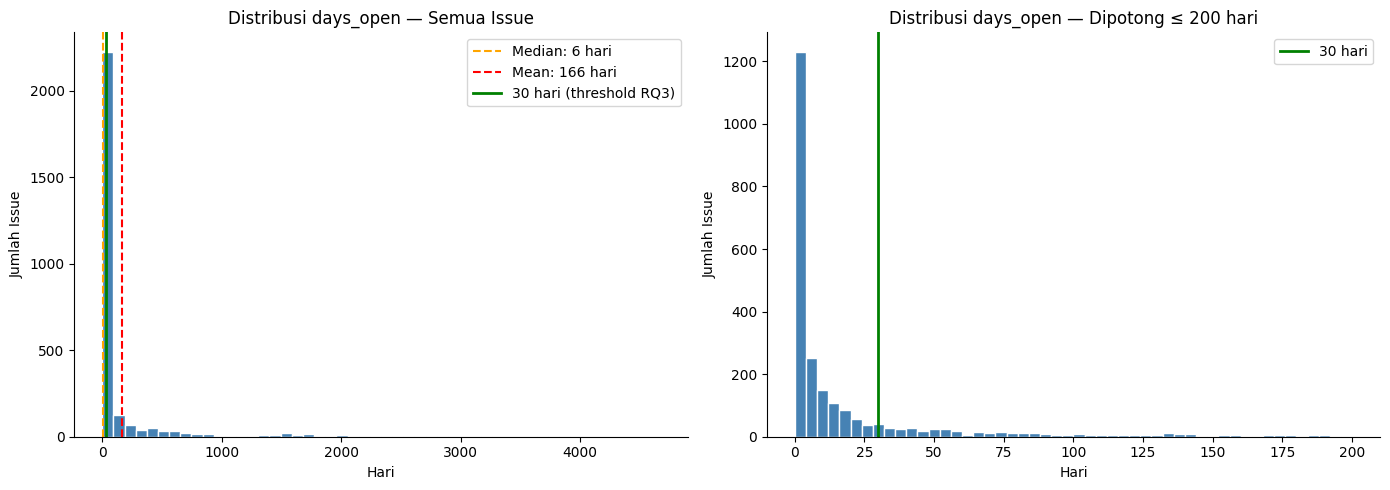

Issue yang terbuka > 30 hari: 29.8%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram semua nilai
axes[0].hist(df_issues['days_open'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df_issues['days_open'].median(), color='orange', linestyle='--',
                label=f"Median: {df_issues['days_open'].median():.0f} hari")
axes[0].axvline(df_issues['days_open'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_issues['days_open'].mean():.0f} hari")
axes[0].axvline(30, color='green', linewidth=2, label='30 hari (threshold RQ3)')
axes[0].set_title('Distribusi days_open — Semua Issue')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Jumlah Issue')
axes[0].legend()

# Histogram dipotong <= 200 hari
clipped = df_issues[df_issues['days_open'] <= 200]['days_open']
axes[1].hist(clipped, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(30, color='green', linewidth=2, label='30 hari')
axes[1].set_title('Distribusi days_open — Dipotong ≤ 200 hari')
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Jumlah Issue')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/clean/plot_days_open_issues.png', dpi=150)
plt.show()

pct_over_30 = (df_issues['days_open'] > 30).mean() * 100
print(f'Issue yang terbuka > 30 hari: {pct_over_30:.1f}%')

**Interpretasi:** Distribusi `days_open` sangat menceng ke kanan (right-skewed). Mayoritas issue diselesaikan dalam waktu singkat, namun terdapat ekor panjang dengan beberapa issue yang terbuka hingga ratusan hari. Persentase issue yang terbuka lebih dari 30 hari akan diestimasi lebih lanjut menggunakan simulasi Monte Carlo tanpa asumsi distribusi tertentu.

## 2.3 Proporsi PR Merged vs Ditolak (RQ1)

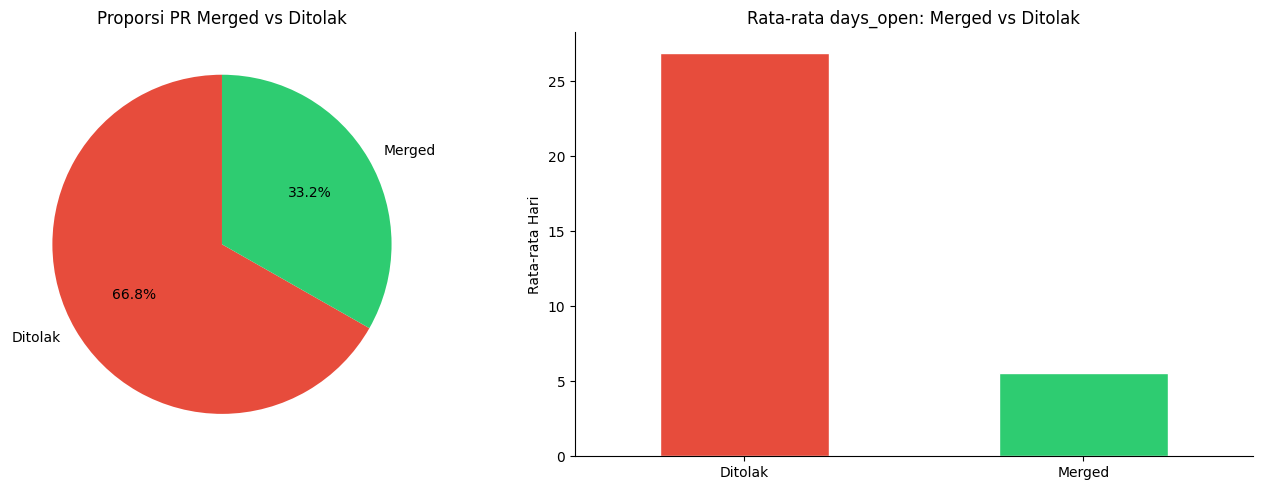

Merge rate : 66.8%
Total merged   : 2,003
Total ditolak  : 997


In [14]:
merge_counts = df_prs['merged'].value_counts()
colors       = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    merge_counts,
    labels=['Ditolak', 'Merged'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Proporsi PR Merged vs Ditolak')

# Bar chart rata-rata days_open
df_prs.groupby('merged')['days_open'].mean().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='white', rot=0
)
axes[1].set_title('Rata-rata days_open: Merged vs Ditolak')
axes[1].set_xlabel('')
axes[1].set_ylabel('Rata-rata Hari')
axes[1].set_xticklabels(['Ditolak', 'Merged'])

plt.tight_layout()
plt.savefig('../data/clean/plot_pr_merged.png', dpi=150)
plt.show()

print(f"Merge rate : {df_prs['merged'].mean()*100:.1f}%")
print(f"Total merged   : {df_prs['merged'].sum():,}")
print(f"Total ditolak  : {(df_prs['merged']==0).sum():,}")

**Interpretasi:** Dari total PR yang ditutup, sebagian besar berhasil di-merge. Nilai merge rate ini menjadi input variabel Bernoulli dengan k = jumlah merged dan n = total PR untuk estimasi MLE oleh Member B.

## 2.4 Tren Issues per Bulan — Sebelum & Sesudah pandas 2.0 (RQ2)

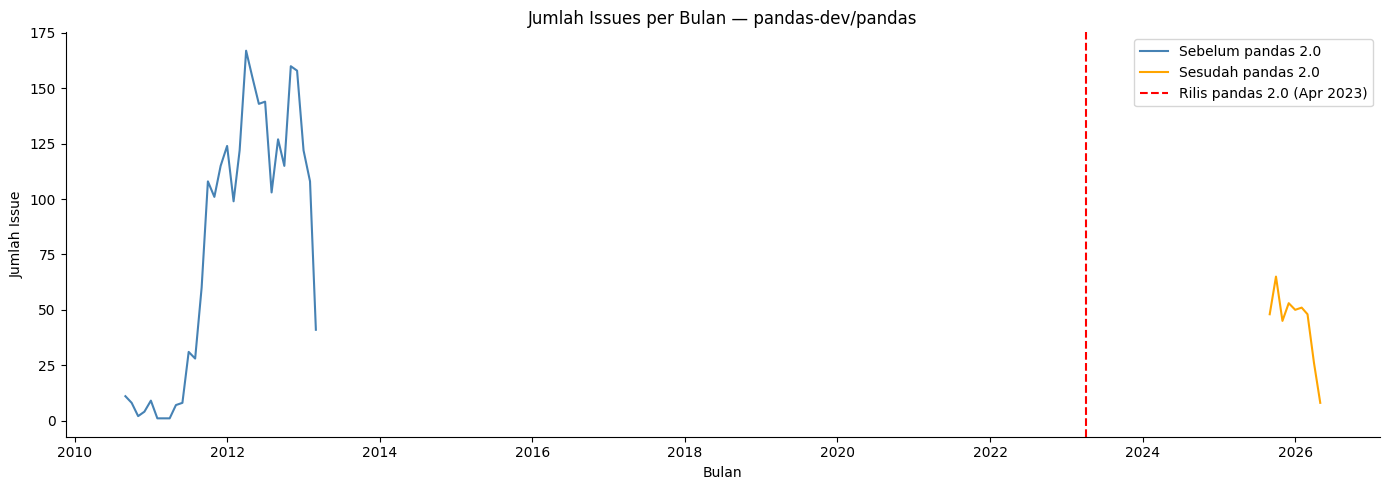

Rata-rata issues/minggu sebelum pandas 2.0 : 22.06
Rata-rata issues/minggu sesudah pandas 2.0 : 10.65


In [15]:
monthly = df_issues.groupby('year_month').size().reset_index(name='count')
monthly['year_month_dt'] = pd.to_datetime(monthly['year_month'])
monthly = monthly.sort_values('year_month_dt')

V2_DATE = pd.Timestamp('2023-04-03')
pre     = monthly[monthly['year_month_dt'] <  V2_DATE]
post    = monthly[monthly['year_month_dt'] >= V2_DATE]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pre['year_month_dt'],  pre['count'],  color='steelblue', label='Sebelum pandas 2.0')
ax.plot(post['year_month_dt'], post['count'], color='orange',    label='Sesudah pandas 2.0')
ax.axvline(V2_DATE, color='red', linestyle='--', linewidth=1.5, label='Rilis pandas 2.0 (Apr 2023)')
ax.set_title('Jumlah Issues per Bulan — pandas-dev/pandas')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Issue')
ax.legend()

plt.tight_layout()
plt.savefig('../data/clean/plot_tren_bulanan.png', dpi=150)
plt.show()

pre_mean  = df_issues[df_issues['post_v2']==0].groupby('week').size().mean()
post_mean = df_issues[df_issues['post_v2']==1].groupby('week').size().mean()
print(f'Rata-rata issues/minggu sebelum pandas 2.0 : {pre_mean:.2f}')
print(f'Rata-rata issues/minggu sesudah pandas 2.0 : {post_mean:.2f}')

**Interpretasi:** Dengan pengambilan data dua arah (pre & post), grafik kini menampilkan tren dari kedua periode. Nilai `lambda_pre_v2` dan `lambda_post_v2` tersedia untuk analisis perbandingan RQ2 oleh Member D.

## 2.5 Distribusi `days_open` — PR Merged vs Ditolak

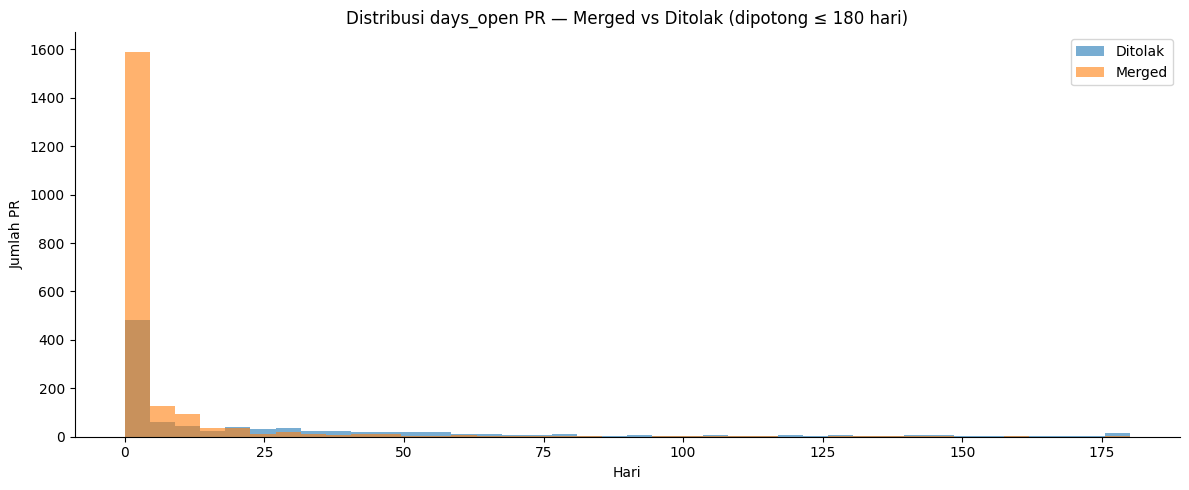

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, grp in df_prs.groupby('merged'):
    nama = 'Merged' if label == 1 else 'Ditolak'
    ax.hist(grp['days_open'].clip(upper=180), bins=40, alpha=0.6, label=nama)

ax.set_title('Distribusi days_open PR — Merged vs Ditolak (dipotong ≤ 180 hari)')
ax.set_xlabel('Hari')
ax.set_ylabel('Jumlah PR')
ax.legend()

plt.tight_layout()
plt.savefig('../data/clean/plot_days_open_prs.png', dpi=150)
plt.show()

**Interpretasi:** Distribusi `days_open` PR yang di-merge cenderung lebih pendek dibanding PR yang ditolak. PR yang berkualitas dan relevan biasanya diproses lebih cepat oleh maintainer, sementara PR yang bermasalah cenderung dibiarkan terbuka lebih lama sebelum akhirnya ditutup tanpa merge.

## 2.6 Top 10 Kontributor

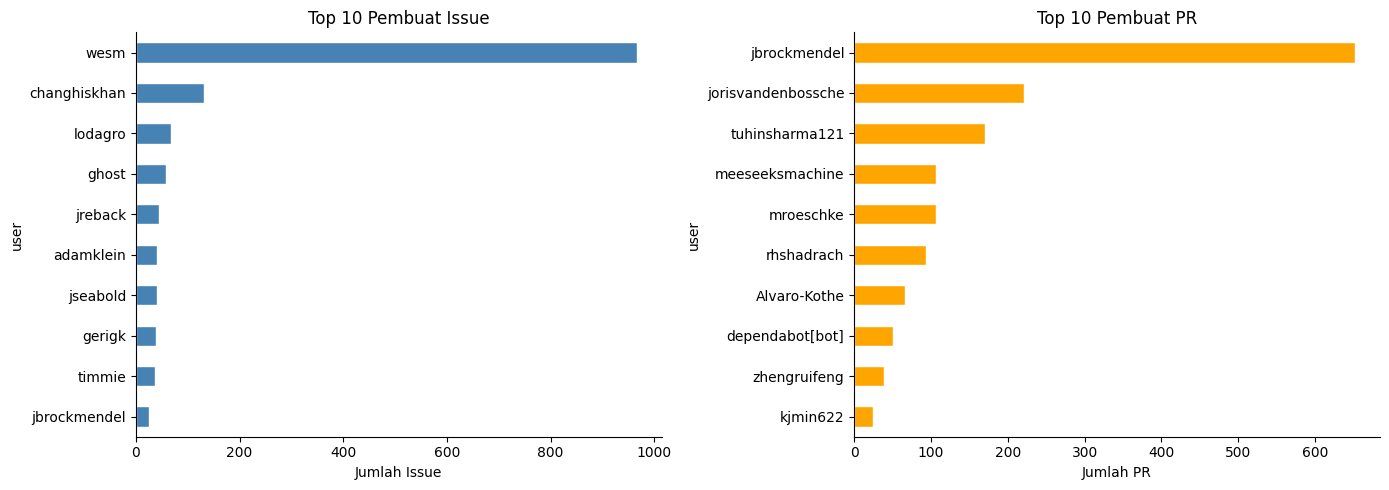

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 pembuat issue
top_issue_users = df_issues['user'].value_counts().head(10)
top_issue_users.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Pembuat Issue')
axes[0].set_xlabel('Jumlah Issue')
axes[0].invert_yaxis()

# Top 10 pembuat PR
top_pr_users = df_prs['user'].value_counts().head(10)
top_pr_users.plot(kind='barh', ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Top 10 Pembuat PR')
axes[1].set_xlabel('Jumlah PR')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../data/clean/plot_top_kontributor.png', dpi=150)
plt.show()

**Interpretasi:** Kontribusi PR pada proyek pandas sangat terkonsentrasi pada sejumlah kecil kontributor inti. Pola ini umum pada proyek open-source besar di mana maintainer tetap mendominasi aktivitas commit dan review.

---
## 2.7 Export Variabel Ringkasan untuk Member Lain

In [ ]:
summary = {
    # Untuk Member B & C — Bernoulli
    'n_prs'           : len(df_prs),
    'k_merged'        : int(df_prs['merged'].sum()),
    'merge_rate'      : round(df_prs['merged'].mean(), 4),

    # Untuk Member B & D — Poisson
    'lambda_pre_v2'   : round(df_issues[df_issues['post_v2']==0].groupby('week').size().mean(), 4),
    'lambda_post_v2'  : round(df_issues[df_issues['post_v2']==1].groupby('week').size().mean(), 4),

    # Untuk Member E — Monte Carlo
    'pct_over_30_days': round((df_issues['days_open'] > 30).mean(), 4),
    'mean_days_open'  : round(df_issues['days_open'].mean(), 4),
    'std_days_open'   : round(df_issues['days_open'].std(), 4),
}

pd.DataFrame([summary]).T.rename(columns={0: 'nilai'}).to_csv('../data/clean/eda_summary.csv')

print('=== Variabel untuk Member B, C, D, E ===')
for k, v in summary.items():
    print(f'  {k:<25} : {v}')

=== Variabel untuk Member B, C, D, E ===
  n_prs                     : 3000
  k_merged                  : 2003
  merge_rate                : 0.6677
  lambda_pre_v2             : 22.0556
  lambda_post_v2            : 10.6486
  pct_over_30_days          : 0.2976
  mean_days_open            : 165.6459
  std_days_open             : 487.6867


---
## Ringkasan & Handoff ke Layer Berikutnya

**Temuan utama EDA:**
1. Merge rate PR tersedia berdasarkan data yang terkumpul, cocok dimodelkan dengan distribusi Bernoulli karena hasilnya biner (merged=1, ditolak=0).
2. Distribusi `days_open` issues sangat menceng ke kanan. Persentase issue yang terbuka lebih dari 30 hari mendukung penggunaan Monte Carlo.
3. Data issues kini mencakup **kedua periode** (sebelum dan sesudah pandas 2.0) sehingga `lambda_pre_v2` dan `lambda_post_v2` keduanya tersedia untuk analisis RQ2.

**Output untuk layer berikutnya:**
| File | Digunakan oleh |
|------|---------------|
| `data/clean/issues_clean.csv` | Member B, D, E |
| `data/clean/prs_clean.csv` | Member B, C |
| `data/clean/eda_summary.csv` | Semua member |